<a href="https://colab.research.google.com/github/abisolami/lagos-rent/blob/main/Lagos_Rent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Lagos Rent Prediction**

![Picture](https://raw.githubusercontent.com/abisolami/lagos-rent/a13b1b66eb8091831b5da80be30187d192a67380/apartment-image.jpg)


---
**PROBLEM STATEMENT**
---
In Lagos,





In [ ]:
# Importing necessary libaries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

#### **Data Collection and Understanding**

In [ ]:
url = 'https://raw.githubusercontent.com/abisolami/lagos-rent/refs/heads/main/lagos-rent%203.csv'
data = pd.read_csv(url)
data.head()

,Title,More Info,Price,Serviced,Newly Built,Furnished,Bedrooms,Bathrooms,Toilets,City,Neighborhood
0,Newly Built 4 Bedroom Semi Detached House With Bq,4 BEDROOM HOUSE FOR RENT,"5,000,000/year",0,1,0,4 beds,4 baths,5 Toilets,Lekki,Agungi
1,Superb 4 Bedroom Semi Detached Duplex With Bq,4 BEDROOM HOUSE FOR RENT,"5,000,000/year",0,1,0,4 beds,4 baths,5 Toilets,Lekki,Other Lekki
2,Furnished 2 Bedroom Terrace Duplex For Rent !!!,2 BEDROOM HOUSE FOR RENT,"3,500,000",1,0,0,2 beds,3 baths,3 Toilets,Lekki,Osapa London
3,2 Bedroom Apartment For Rent,2 BEDROOM HOUSE FOR RENT,"2,700,000",1,1,0,2 beds,3 baths,3 Toilets,Lekki,Ologolo
4,4 Bedroom Terrace Duplex For Rent,4 BEDROOM HOUSE FOR RENT,"4,000,000",1,0,0,4 beds,5 baths,5 Toilets,Lekki,Chevron


In [ ]:
# checking for number of rows and columns
print(f'Rows and Columns of the datasets: {data.shape}\n')
print(f'Datatypes of the features in the dataset: \n{data.dtypes}')

Rows and Columns of the datasets: (53070, 11)

Datatypes of the features in the dataset: 
Title           object
More Info       object
Price           object
Serviced         int64
Newly Built      int64
Furnished        int64
Bedrooms        object
Bathrooms       object
Toilets         object
City            object
Neighborhood    object
dtype: object


The dataset contain essential features such
- Title:  The description of the apartment of house available for rent
- More Info: A detailed description of the apartment (Flat/ Mini flat/ House)
- Price: The cost of the apartment, i.e the rent
- Serviced: Confirms whether the apartment is a shortlet or not
- Newly Built: Tells if the apartment is new  or not
- Furnished: Confirms if the apartment is fully furnished or not
- Bedrooms: This states the number of bedroom in the apartment
- Bathrooms: This states the number of bathrooms in the apartment
- Toilets: This states the number of Toilets in the apartment
- City: The City which the apartment is located
- Neighborhood: The neighborhood of the apartment
---
---
A total of 11 features and 53,070 instances

#### **Data Cleaning**

In [ ]:
# Checking for NaN values
data.isna().sum()

,0
Title,0
More Info,0
Price,0
Serviced,0
Newly Built,0
Furnished,0
Bedrooms,0
Bathrooms,0
Toilets,0
City,0


In [ ]:
# checking for duplicate values

data.duplicated().sum()

np.int64(1883)

There are *no feature in the dataset with a null value* and *there are no duplicate values*


**Data Type Conversion**

In [ ]:
# striping the price feature
# data['Price'] = data['Price'].str.replace(',', '').str.replace('/year', '').str.replace('/month', '').str.replace('/day', '').str.replace('/sqm', '')

# will return to use regex instead
pattern = r',|/year|/month|/day|/sqm'
data['Price'] = data['Price'].str.replace(pattern, '', regex=True)

# get rid of whitespaces
data['Price'] = data['Price'].str.strip()
# converting the price datatype to integer
data['Price'] = pd.to_numeric(data['Price'], errors='coerce').astype('Int64')


In [ ]:
# Cleaning the Bedroom, Toilet and Bathroom featute
columns_to_clean = ['Bathrooms', 'Bedrooms', 'Toilets']

for col in columns_to_clean:
  # getting the first part of the string
  data[col] = data[col].str.split().str[0]
  # now converting to integers
  data[col] = pd.to_numeric(data[col], errors='coerce').astype('Int64')

In [ ]:
data.head(2)

,Title,More Info,Price,Serviced,Newly Built,Furnished,Bedrooms,Bathrooms,Toilets,City,Neighborhood
0,Newly Built 4 Bedroom Semi Detached House With Bq,4 BEDROOM HOUSE FOR RENT,5000000,0,1,0,4,4,5,Lekki,Agungi
1,Superb 4 Bedroom Semi Detached Duplex With Bq,4 BEDROOM HOUSE FOR RENT,5000000,0,1,0,4,4,5,Lekki,Other Lekki


Now, the dataset is clean enough for other analysis and visualization as the **Price, Bedrooms, Bathroom** and **Toilets** features have been properly processed

**Cleaning the Target Variable (Price)**

In [ ]:
print(f"The highest cost of renting an apartment in Lagos is {data['Price'].max()}")
print(f"The lowest cost of renting an apartment in Lagos is {data['Price'].min()}")

# Count how many are suspiciously high (say above ₦100 million)
high_prices = data[data['Price'] > 100_000_000]

print(f"Number of suspicious values: {len(high_prices)}")
high_prices[['Price']].head(10)



The highest cost of renting an apartment in Lagos is 1700000000000
The lowest cost of renting an apartment in Lagos is 1
Number of suspicious values: 244


,Price
239,130000000
262,2700000000
263,1500000000
531,170000000
554,120000000
603,120000000
884,180000000
1307,450000000
1621,250000000
2054,250000000


It's been observed that **Price** feature in the dataset contains some ***Suspecious values***. As the highest price of an apartment in Lagos was recorded as 1,700,000,000 and the lowest price is 1.

**How is it possible the cost of renting an apartment in Lagos is over 1 Bilion? And who rent out an apartment for N1?**
---
About *244* rows shows the rent of over **100 million** which is almost impossible.

To resolve this, I got rid of the outliers by dropping instances in the dataset that were less than **50,000** and more than **10 million.**
Leaving about **4000 instances** to be dropped, which is roughly about **7.5%** of the dataset.



In [ ]:
# dropping rows with prices less than 10000 and prices more that 10000000
data = data[(data['Price'] >= 50000) & (data['Price'] <= 10000000)]
data.shape

(48883, 11)

In [ ]:
# percentage of rows that were removed
rate = 100 - ((data.shape[0]/53070) * 100)
print(f"Percentage of rows that were removed: {rate:.2f}%")


Percentage of rows that were removed: 7.89%


#### **Exploratory Data Analysis**

###### **Target Variable**

**Exploring the Rent price**

In [ ]:
print(f"Now the highest amount of rent paid by a Lagosian is {data['Price'].max()}, while the lowest amount of rent paid by a Lagosian is {data['Price'].min()}")


Now the highest amount of rent paid by a Lagosian is 10000000, while the lowest amount of rent paid by a Lagosian is 50000


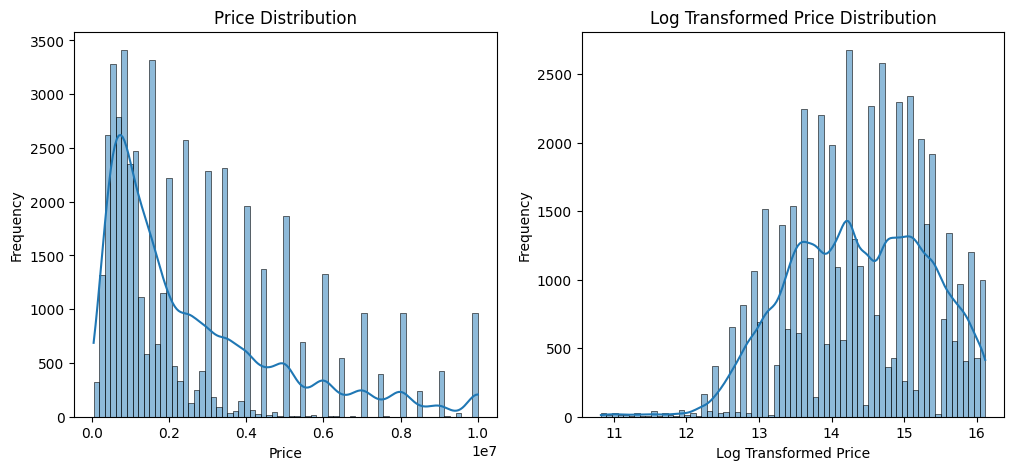

In [ ]:
# visualizing the price distribution in two column

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data['Price'], kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

# log transformed price
plt.subplot(1,2,2)
sns.histplot(np.log1p(data['Price']), kde=True)
plt.title('Log Transformed Price Distribution')
plt.xlabel('Log Transformed Price')
plt.ylabel('Frequency')

# plt.tight_layout()
plt.show()

From the distribution above, at the Left hand side is the actual **Price Distribution** after reducing the outliers. It appears that the distribution of the price is **positively skewed** as the tail moves towards the right hand side.

To *normalize the skewness*, the distribuion was transformed using **Logarithmic Transformation**, giving the visualization at the Right hand side.

---

**For some reason that looks like its now negatively skewd, I'll be back**

In [ ]:
# adding the LogTransformed Price extracted from the price feature
data['LogTransformPrice'] = np.log1p(data['Price'])
data[['LogTransformPrice', 'Price']]

,LogTransformPrice,Price
0,15.424949,5000000
1,15.424949,5000000
2,15.068274,3500000
3,14.808763,2700000
4,15.201805,4000000
...,...,...
53065,13.122365,500000
53066,12.899222,400000
53067,13.304687,600000
53068,13.764218,950000


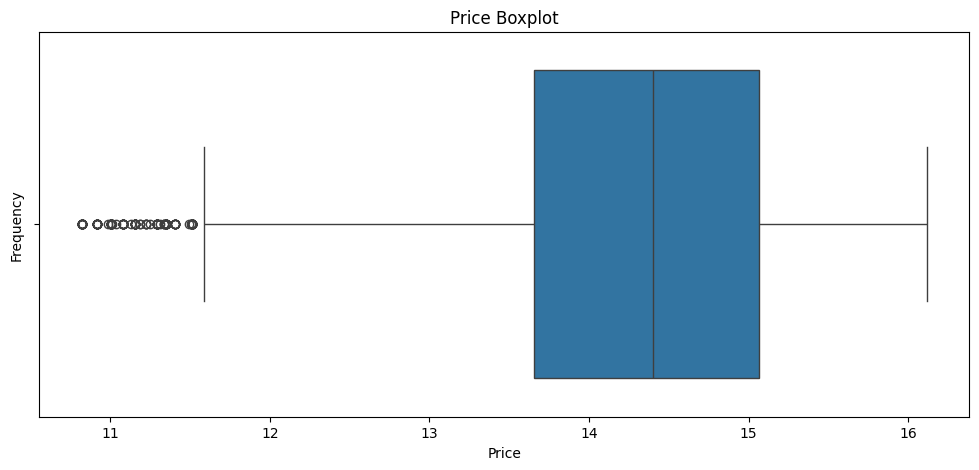

In [ ]:
# checking for outliers in two columns for the normal and log transformed price
plt.figure(figsize=(12,5))
sns.boxplot(data=data, x='LogTransformPrice')
plt.title('Price Boxplot')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


Even after ...

**Analyzing the Distribution of certain features**


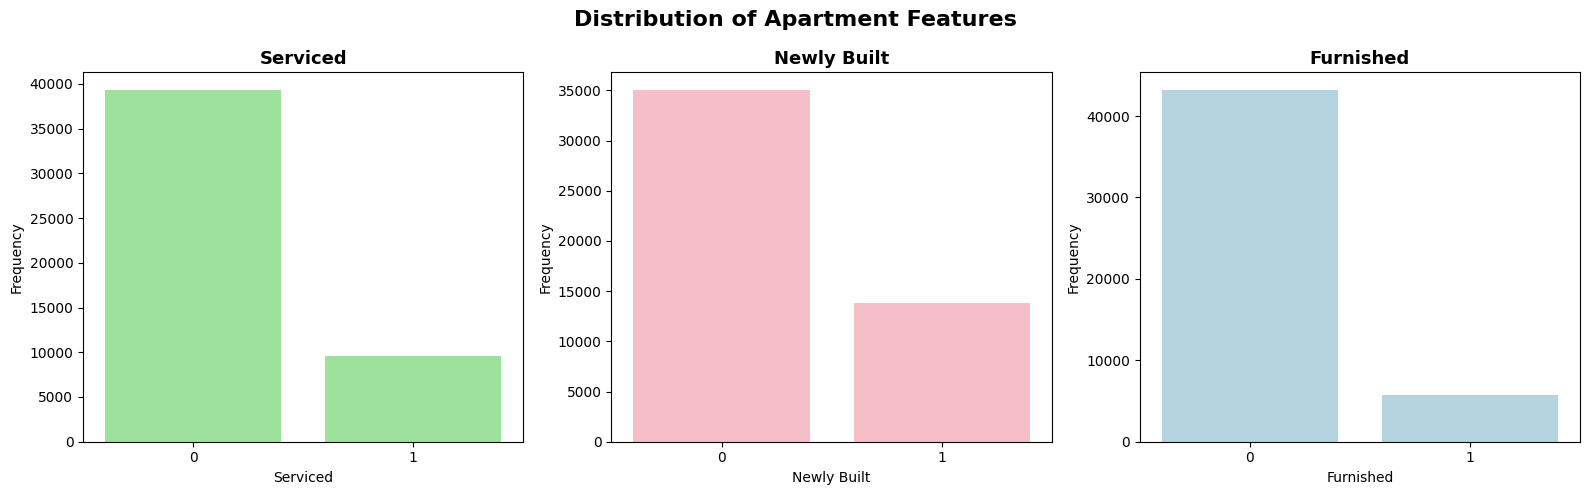


Serviced
0    39329
1     9554
Name: count, dtype: int64

Newly Built
0    35040
1    13843
Name: count, dtype: int64

Furnished
0    43203
1     5680
Name: count, dtype: int64


In [ ]:
features_to_visualize = ['Serviced', 'Newly Built', 'Furnished']
colors = ['lightgreen', 'lightpink', 'lightblue']

# Create a single figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature, color in zip(axes, features_to_visualize, colors):
    sns.countplot(data=data, x=feature, color=color, ax=ax)
    ax.set_title(f'{feature}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.set_xlabel(f'{feature}')


fig.suptitle('Distribution of Apartment Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

for feature in features_to_visualize:
  print(f"\n{data[feature].value_counts()}")

/tmp/ipython-input-1794558477.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=feature, y='Price', ax=ax, palette='pastel')
/tmp/ipython-input-1794558477.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=feature, y='Price', ax=ax, palette='pastel')
/tmp/ipython-input-1794558477.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=feature, y='Price', ax=ax, palette='pastel')


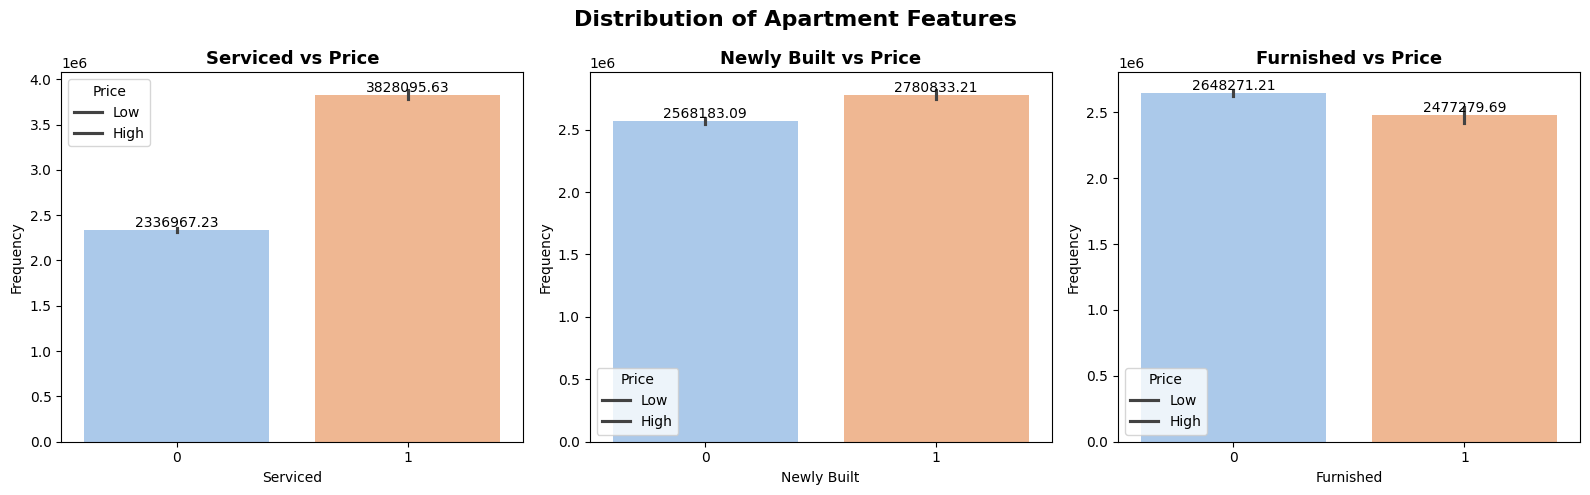

In [ ]:
# Checking the visualization of features_to_visualize against price all in a row
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature in zip(axes, features_to_visualize):
  sns.barplot(data=data, x=feature, y='Price', ax=ax, palette='pastel')
  ax.set_title(f'{feature} vs Price', fontsize=13, fontweight='bold')
  ax.set_ylabel('Frequency')
  ax.set_xlabel(f'{feature}')
  ax.legend(title='Price', labels=['Low', 'High'])

  for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

fig.suptitle('Distribution of Apartment Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()




From the visualization above, ....

##### **Numerical Variables**

**Visualzing the Numerical Data**

In [ ]:
# Extracting the numerical data
num_data = data.select_dtypes(include=['int64'])
numerical_data = num_data.drop(columns=['Newly Built', 'Furnished', 'Serviced'])
numerical_data

,Price,Bedrooms,Bathrooms,Toilets
0,5000000,4,4,5
1,5000000,4,4,5
2,3500000,2,3,3
3,2700000,2,3,3
4,4000000,4,5,5
...,...,...,...,...
53065,500000,1,2,2
53066,400000,1,1,1
53067,600000,2,2,3
53068,950000,3,2,2



Visualizing the Price Distribution
Skewness: 1.3361332839198545


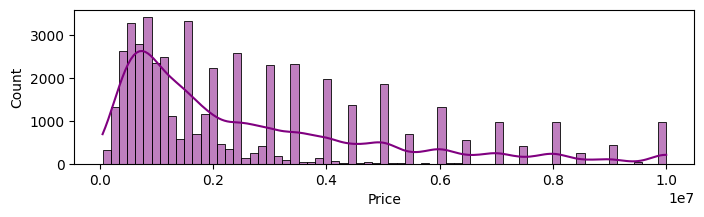


Visualizing the Bedrooms Distribution
Skewness: nan


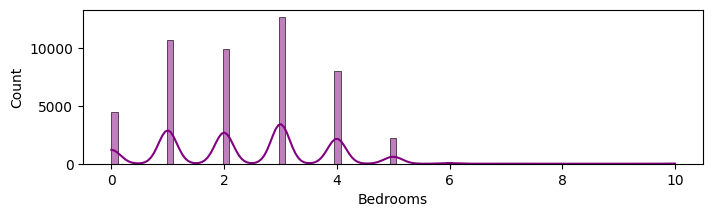


Visualizing the Bathrooms Distribution
Skewness: nan


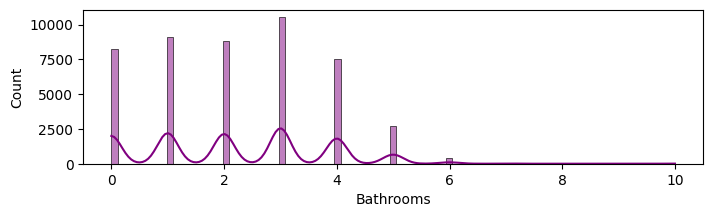


Visualizing the Toilets Distribution
Skewness: nan


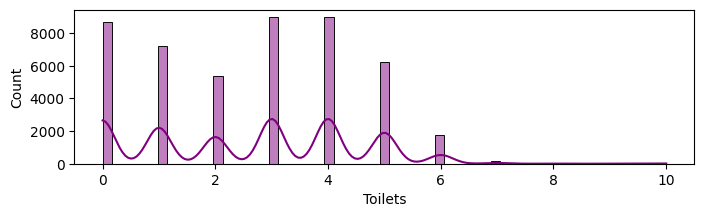

In [ ]:
# visualizing each
for col in numerical_data:
  print(f'\nVisualizing the {col} Distribution\nSkewness: {skew(numerical_data[col])}')

  plt.figure(figsize=(8,2))
  sns.histplot(data=data, x=col, kde=True, color='purple')
  plt.show()

The histograms above shows...

**Analyzing the relationship with Prices and other apartment features**

In [ ]:
# # visualizing how prices vary with the number of Bathrooms, Toilet and Bedrooms
# plt.figure(figsize=(18,5))
# plt.subplot(1,3,1)
# sns.boxplot(data=data, x='Bedrooms', y='LogTransformPrice')
# plt.title('Relationship Between Price and Number of Bedrooms')
# plt.xlabel('Bedrooms')
# plt.ylabel('Price')
# plt.show()

# plt.subplot(1,3,2)
# sns.boxplot(data=data, x='Toilets', y='LogTransformPrice')
# plt.title('Relationship Between Price and Number of Toilets')
# plt.xlabel('Toilets')
# plt.ylabel('Price')
# plt.show()

# plt.subplot(1,3,3)
# sns.boxplot(data=data, x='Bathrooms', y='Price')
# plt.title('Relationship Between Price and Number of Bathrooms')
# plt.xlabel('Bathrooms')
# plt.ylabel('Price')
# plt.show()

**OMG, all I see in anomalies.**

**BE RIGHT BACK**

**Correlation Analysis**

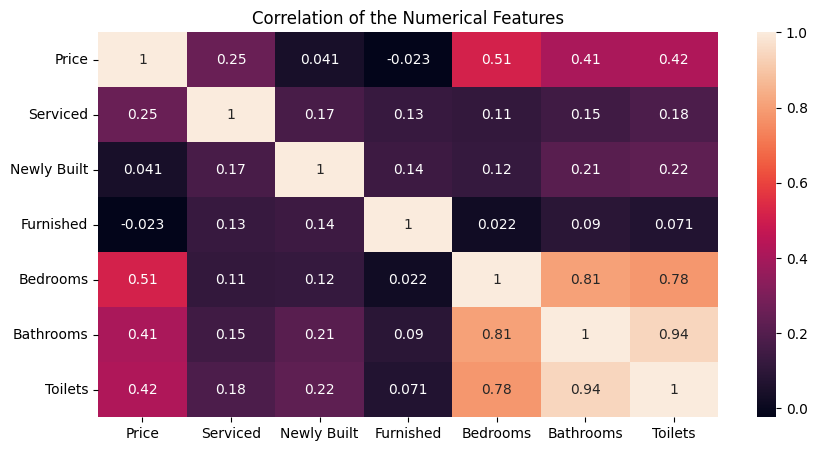

In [ ]:
# visualizing the heatmap of the numerical data
plt.figure(figsize=(10,5))
sns.heatmap(num_data.corr(), annot=True)
plt.title('Correlation of the Numerical Features')
plt.show()

The number of **Bedrooms** in the apartments is the only one that correlates slightly with the **Price** of the apartment. Other numerical feature has little to no correlation with the price.

##### **Categorical Variable**

**Exploring the relationship with other categorical variable and the price**.


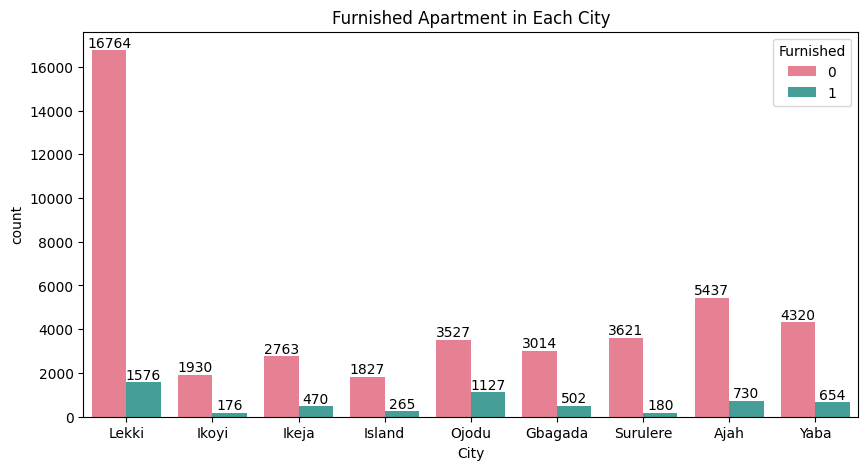

In [ ]:
# exploring the if Furnished apartment varies with the City
plt.figure(figsize=(10,5))
ax = sns.countplot(data=data, x='City', hue='Furnished', palette='husl')
plt.title('Furnished Apartment in Each City')

for container in ax.containers:
  ax.bar_label(container, fmt='%d') # to print  the exact counts of each apartment

plt.show()

All Cities in the dataset have more **Non-Furnished** apartment more than the **Furnished**

Cities like Lekki...

**Variation with Neighborhood/Cities with Prices**

/tmp/ipython-input-1385554442.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=data, x='City', y='Price', estimator=np.mean, palette='inferno')


Text(0, 0.5, 'Average Price')

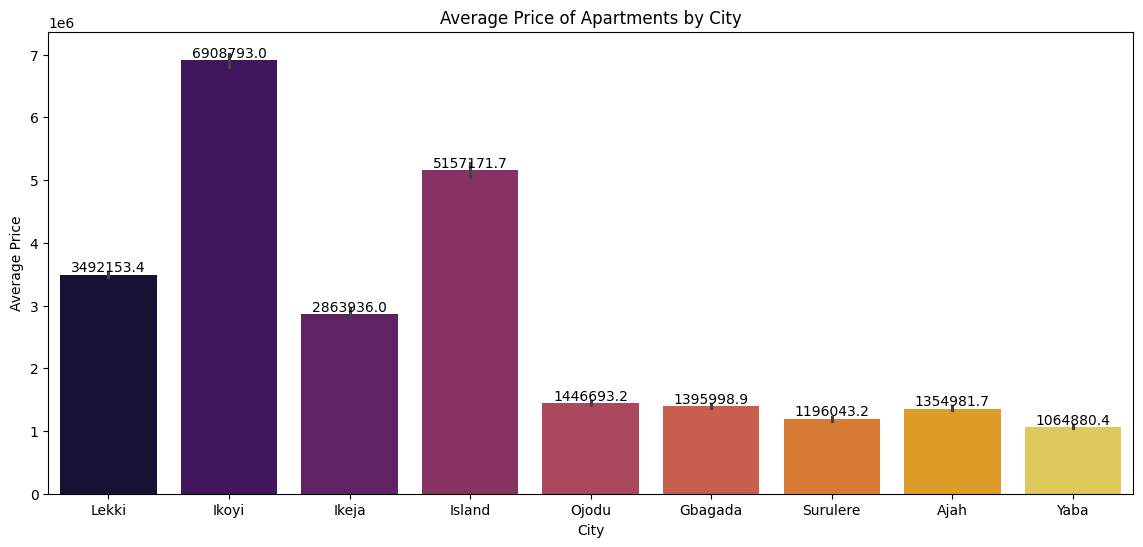

In [ ]:
# Visualizing the variation in average prices across different Cities
plt.figure(figsize=(14,6))
ax = sns.barplot(data=data, x='City', y='Price', estimator=np.mean, palette='inferno')

for container in ax.containers:
  ax.bar_label(container, fmt='%.1f')
plt.title('Average Price of Apartments by City')
plt.xlabel('City')
plt.ylabel('Average Price')

The City with the **highest average price** for an apartment is ***Ikoyi***, with an average price of **N6,908,793.00**.

Then ***Island*** and ***Lekki*** with average price of **N5,157,171.70** and **N3,492,153.40** respectively.

The least mean price is Yaba with an average of N1,064,880.40.

***Observation: The location is an important factor to consider before renting an apartment in Lagos, as it depends on the price of the apartment***

**Analyzing the relationship between newly built houses and the neighborhood**

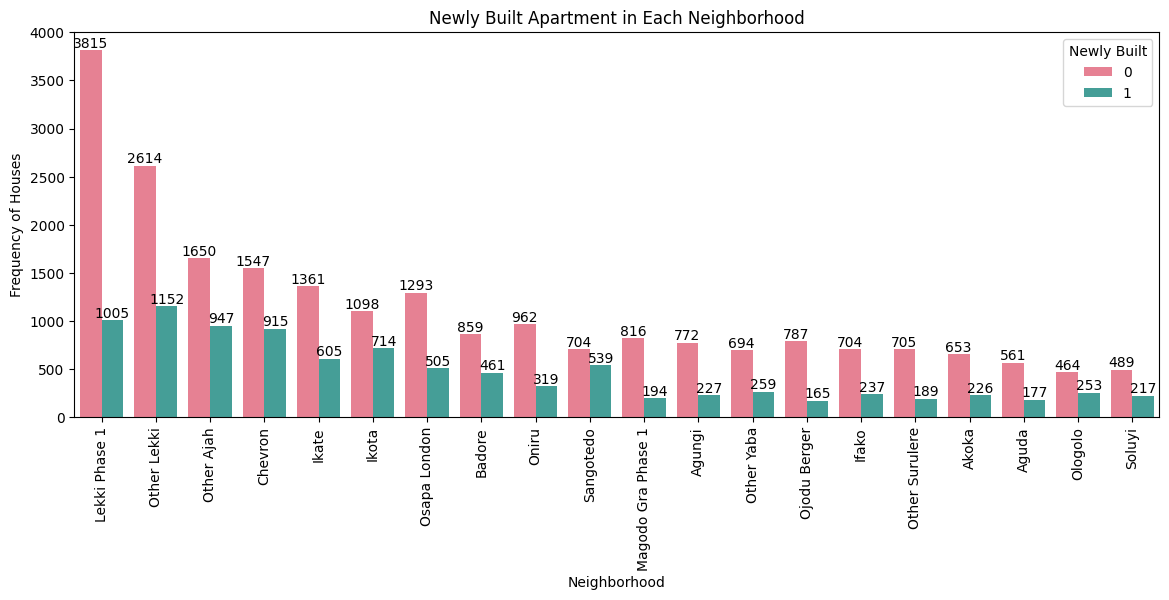

In [ ]:
# visualizing the relationship with the newly built and top neighborhood

# extracting only the top 20 neighborhoods out of the 69 available
top_20_neighborhoods = data['Neighborhood'].value_counts().head(20).index.tolist()

neighborhood_data = data[data['Neighborhood'].isin(top_20_neighborhoods)]


plt.figure(figsize=(14,5))
ax = sns.countplot(data=neighborhood_data, x='Neighborhood', hue='Newly Built', order=top_20_neighborhoods, palette='husl')

for container in ax.containers:
  ax.bar_label(container, fmt='%d')

plt.title('Newly Built Apartment in Each Neighborhood')
plt.xlabel('Neighborhood')
plt.xticks(rotation=90)
plt.ylabel('Frequency of Houses')
plt.show()

There seems to be *less* **Newly Built** houses in all **Neighborhood**.

However, Neighborhoods like ***Other Lekki, Lekki phase 1*** and **Other Ajah** has more Newly Built Neighborhood compared to the rest of the Neigborhood.

In [ ]:
data['Neighborhood'].value_counts().tail(10).index


Index(['Gbagada Phase 1', 'Ojuelegba', 'alausa', 'Victoria Island Extension',
       'Dolphin Estate', 'Awolowo Road', 'Adeola Odeku', '1004',
       'Ligali Ayorinde', 'Bourdillon'],
      dtype='object', name='Neighborhood')

... and **Neighborhoods** with least records in the dataset are listed above

**Grouping Neighborhoods by Cities**

In [ ]:
# getting the total number of neighborhood for each city
# data.groupby('City')['Neighborhood'].nunique()


Lekki has a total of 8 Neighborhoods


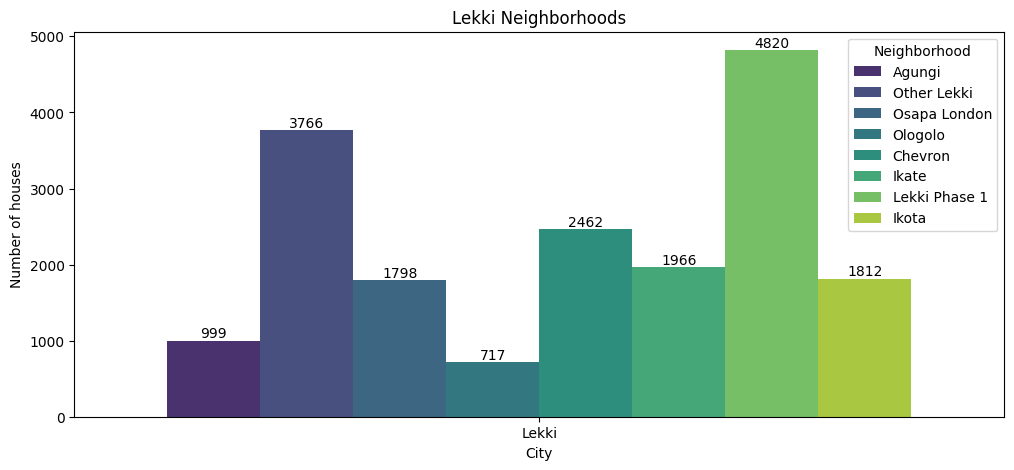


Ikoyi has a total of 8 Neighborhoods


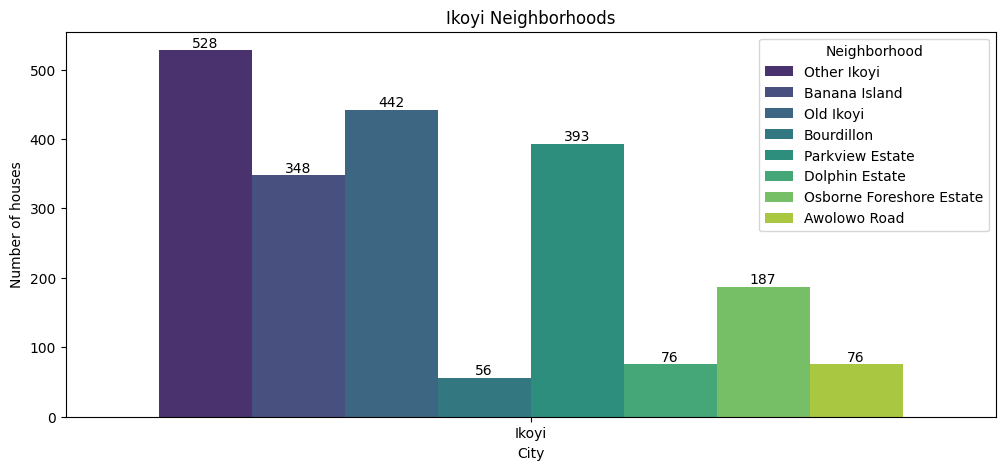


Ikeja has a total of 9 Neighborhoods


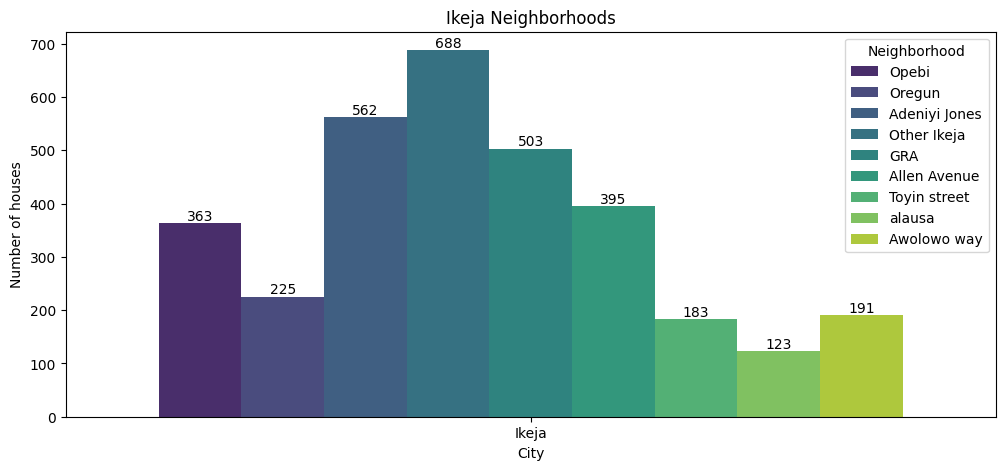


Island has a total of 6 Neighborhoods


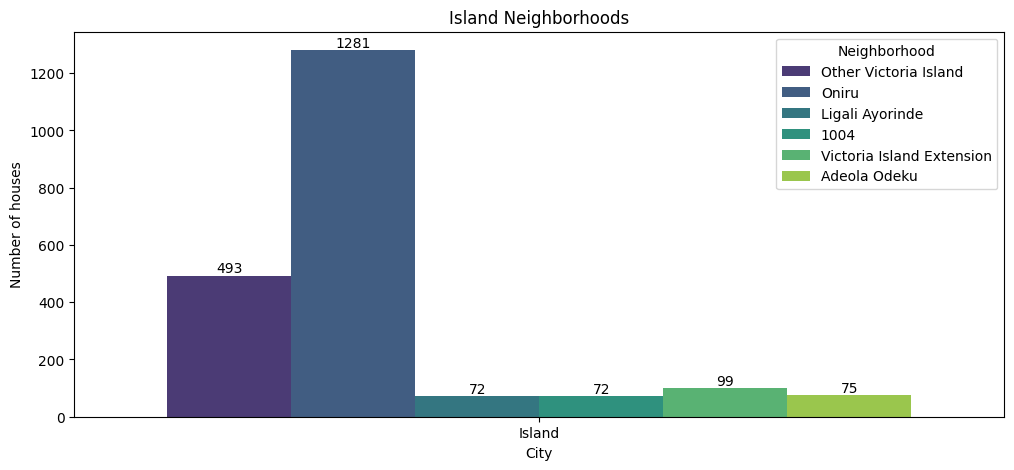


Ojodu has a total of 7 Neighborhoods


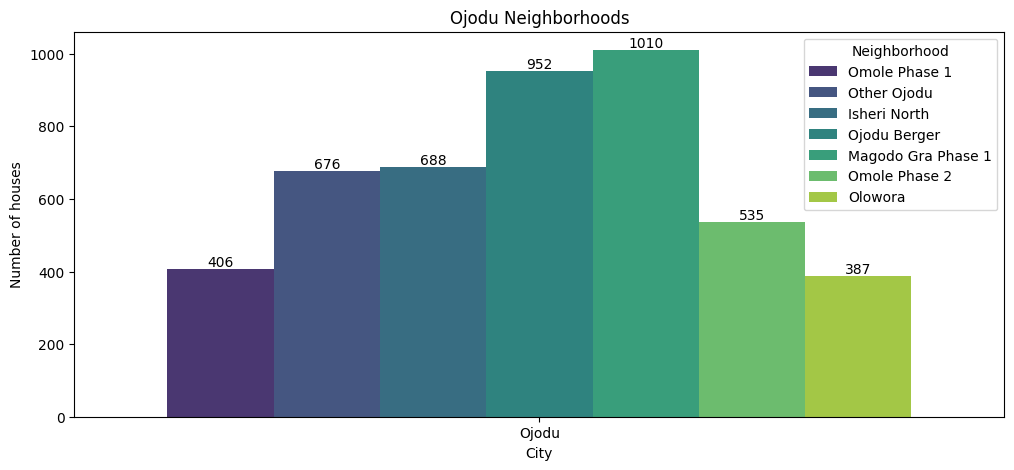


Gbagada has a total of 8 Neighborhoods


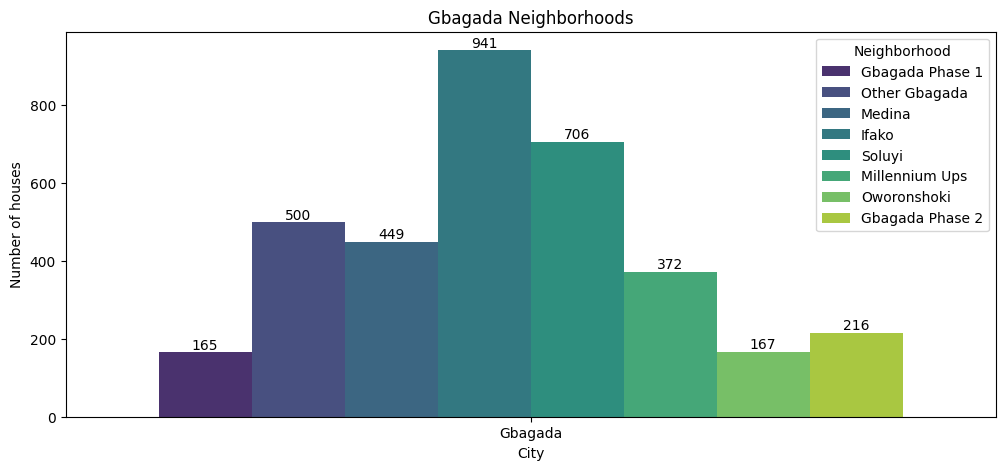


Surulere has a total of 10 Neighborhoods


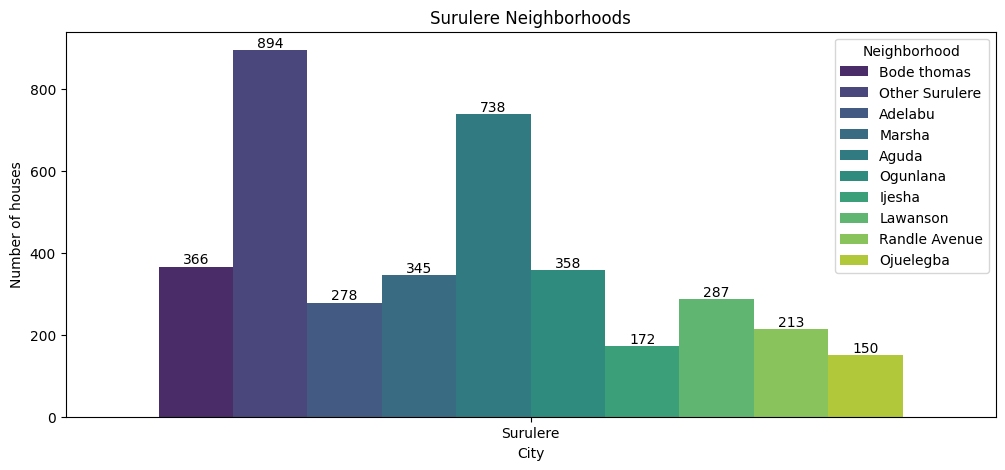


Ajah has a total of 5 Neighborhoods


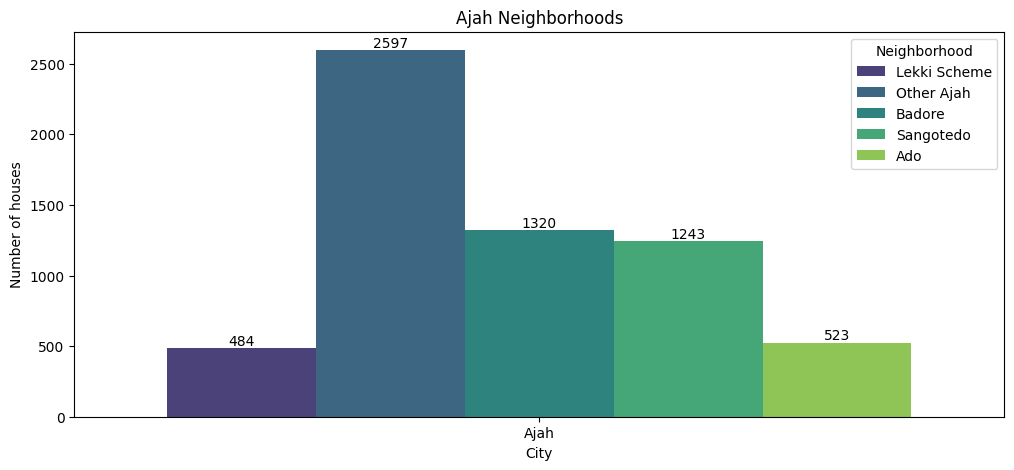


Yaba has a total of 9 Neighborhoods


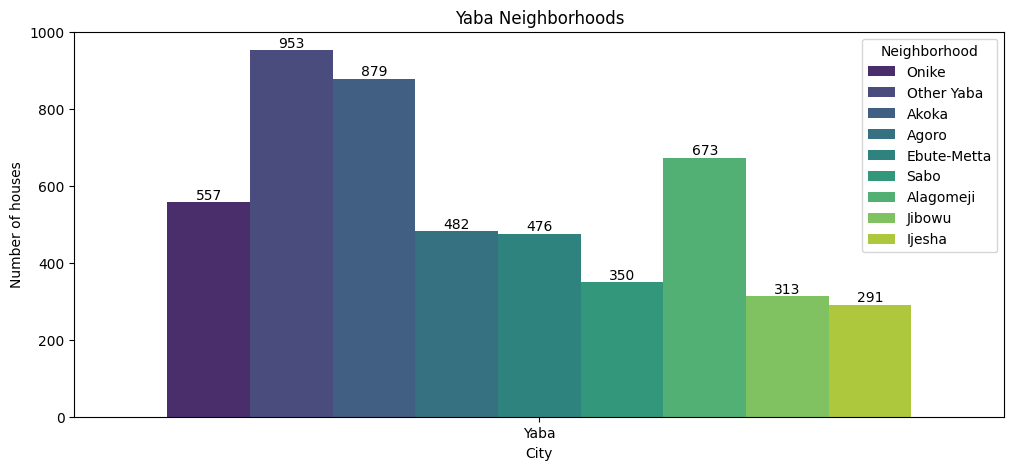

In [ ]:
data.groupby('City')['Neighborhood'].size()

# visualizing each neighboorhood in each city
for city in data['City'].unique():
  # getting the total number of neighborhood for each city
  neigh_city = data[data['City'] == city]['Neighborhood'].nunique()
  print(f"\n{city} has a total of {neigh_city} Neighborhoods")


  plt.figure(figsize=(12,5))
  ax = sns.countplot(data=data[data['City'] == city], x='City', hue='Neighborhood', palette='viridis')

  for container in ax.containers:
    ax.bar_label(container, fmt='%d')

    plt.title(f'{city} Neighborhoods')
    plt.ylabel('Number of houses')
  plt.show()


Feeling overwhelmed? I'll explain ✌

So the visualization above illustrates the total number of houses in each **Neighborhood** based on their respective **Cities**.  

There are a total of 9 cities recorded in the dataset, and each city has a number of neighborhood.

Description:
1.   Lekki - 8 Neighborhoods
2.   Ikoyi - 8 Neighborhoods
3.   Ikeja - 9 Neighborhoods
4.   Island - 6 Neighborhoods
5.   Ojudu - 7 Neighborhoods
6.   Gbagada - 8 Neighborhoods
7.   Surulere - 10 Neighborhoods
8.   Ajah - 5 Neighborhoods
9.   Yaba - 9 Neighborhoods

Now each Neighborhood has a certain number of houses/apartment recorded in the dataset.

***Observation:***  *The most recorded **Neighborhood** is **Lekki phase 1** and **Other Lekki** with **4820** and **3726** respective both in the **City** of **Lekki***.
And the Neighborhood with the least amount of rented apartment in the dataset is  **Bourdillon** in **Ikoyi** with **56** recorded and **Ligali Ayorinde** in Island with **72**.

### **MODELLING**

The main aim of the project is build a model that can easily predict the price of an apartment based on user's input.

The dataset will be split, trained on different regression models and tested using the required metrics.


*Highlighting the features necessary in training the model before splitting the dataset*

1.   Title        -    Not Needed
2.   More Info    -    Not Needed
3.   Price        -    **TARGET VARIABLE**
4.   Serviced     -    Needed
5.   Newly Built  -    Needed
6.   Furnished    -    Needed
7.   Bedrooms     -    Needed
8.   Bathrooms    -    Needed
9.   Toilets      -    Needed
10.  City         -    Needed
11.  Neighborhood -    Needed



In [ ]:
print(f"Right now, the dataset has {data.shape[0]} samples")

Right now, the dataset has 48883 samples


In [ ]:
!pip install streamlit -q
# !npm install localtunnel # Or !pip install pyngrok for ngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 68.5 MB/s eta 0:00:00


In [ ]:
# for modelling
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

import joblib
from google.colab import files
import streamlit as st

In [ ]:
X = data.drop(['Title', 'More Info', 'Price', 'LogTransformPrice', 'Furnished', 'Newly Built'], axis=1)   #independent variable/
y = data['LogTransformPrice']  #dependent variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, )

**Model Selection**

The model will be trained using the following regressive models


*   Linear Regression
*   Decision Tree
*   Random Forest
*   XGBoost Regressor




In [ ]:
# preprocessing the numerical and categorical features before modelling

numeric = ['Bathrooms', 'Bedrooms', 'Toilets']
categorical = ['Serviced', 'City', 'Neighborhood']

preprocess = ColumnTransformer([
    ('numerical', Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())]), numeric),
    ('category', OneHotEncoder(handle_unknown='ignore'), categorical)
])

**Linear Regression**

In [ ]:
# now using the linear regression
model = Pipeline([
    ('preprocess', preprocess),
    ('linReg', LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
# Evaluating
print(f"Root Mean Square Error: {root_mean_squared_error(y_test, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")
print(f"R2: {r2_score(y_test, y_pred)}")

# converting back to actual price


Root Mean Square Error: 0.5948520293480548
Mean Absolute Error: 0.4135009684785297
R2: 0.5998024112586555


Using Linear Regression model is simple but not enough for this complex housing dat

The **RMSE** and **MAE** shows the model's prediction are off by 40-60% on average.

The R2 at 0.60 suggests that the model roughly explains about **60**% **of** **the** **variation** in Price

**Decison Tree**

In [ ]:
model = Pipeline([
    ('preprocess', preprocess),
    ('decTree', DecisionTreeRegressor(random_state=42))
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
# evaluating
print(f"Root Mean Square Error: {root_mean_squared_error(y_test, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")
print(f"R2: {r2_score(y_test, y_pred)}")


Root Mean Square Error: 0.5245873467528397
Mean Absolute Error: 0.3568866033313588
R2: 0.6887623019098856


**Decision Tree Regressor** performs better than the Linear Regression as it catches the **non-linear** **relationship** in Price and other features

R2 - 0.68 explains 68% of price variance. Better than **Linear Regression** but the decision trees can easily overfit, it might not generalize as well to unseen data

**Random Forest**

In [ ]:
model = Pipeline([
    ('preprocess', preprocess),
    ('randomForest', RandomForestRegressor(random_state=42, n_estimators=200, max_depth=15, min_samples_split=5,))
])

model = model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
# evaluating
print(f"Root Mean Square Error: {root_mean_squared_error(y_test, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")
print(f"R2: {r2_score(y_test, y_pred)}")


Root Mean Square Error: 0.5112358539748785
Mean Absolute Error: 0.3525582039086692
R2: 0.7044035725980414


The **Random Forest** improves further than the Linear and the Decision Tree as the **Root Mean Square Error (RMSE) and the Mean Absolute Error (MAE)** drops slightly.

R2 score - The model now explains 70% of the price variation.

**XGBOOST REGRESSOR**

In [ ]:
xgb_model = Pipeline([
    ('preprocess', preprocess),
    ('xgb', XGBRegressor(random_state=42))
])
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

In [ ]:
# evaluating
print(f"Root Mean Square Error: {root_mean_squared_error(y_test, y_pred)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}")
print(f"R2 score: {r2_score(y_test, y_pred)}")

Root Mean Square Error: 0.5044956803321838
Mean Absolute Error: 0.3463495969772339
R2 score: 0.712146520614624


Among all the tested models, the XGBoost Regressor performed best.

With an R2 score of over 0.71, meaning the model explains 71% of variation in price

**Model Deployment**

In [ ]:
# testing
sample = pd.DataFrame([{
    'Serviced': 'Yes',
    'Newly Built': 'Yes',
    'Furnished': 'No',
    'Bedrooms': 3,
    'Bathrooms': 2,
    'Toilets': 2,
    'Neighborhood': 'Other Lekki',
    'City': 'Lekki'
}])

pred = xgb_model.predict(sample)[0]
print(f"The predicted price is {(np.expm1(pred))}")

The predicted price is 2534835.75


In [ ]:
# create new file
joblib.dump(xgb_model, 'model.pkl')
# download
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This should create a file named **best_model_pk1** and download it to PC

In [ ]:
# !pip install streamlit py.ngrok


In [ ]:
# 1. Save and download the corrected app.py
with open('app.py', 'w') as f:
    f.write('''import streamlit as st
import joblib
import numpy as np
import pandas as pd

# Page configuration
st.set_page_config(
    page_title="Lagos Rent Price Predictor",
    page_icon="",
    layout="wide"
)

# Define cities and neighborhoods
LOCATIONS = {
    'Lekki': ['Agungi', 'Other Lekki', 'Osapa London', 'Ologolo', 'Chevron', 'Ikate', 'Lekki Phase 1', 'Ikota'],
    'Ikoyi': ['Other Ikoyi', 'Banana Island', 'Old Ikoyi', 'Bourdillon', 'Parkview Estate', 'Dolphin Estate', 'Osborne', 'Foreshore Estate', 'Awolowo Road'],
    'Ikeja': ['Opebi', 'Oregun', 'Adeniyi Jones', 'Other Ikeja', 'GRA', 'Allen Avenue', 'Toyin street', 'alausa', 'Awolowo way'],
    'Island': ['Other Victoria Island', 'Oniru', 'Ligali Ayorinde', '1004', 'Victoria Island Extension', 'Adeola Odeku'],
    'Ojodu': ['Omole Phase 1', 'Other Ojodu', 'Isheri North', 'Ojodu Berger', 'Magodo Gra Phase 1', 'Omole Phase 2', 'Olowora'],
    'Gbagada': ['Gbagada Phase 1', 'Other Gbagada', 'Medina', 'Ifako', 'Soluyi', 'Millennium Ups', 'Oworonshoki', 'Gbagada Phase 2'],
    'Surulere': ['Bode thomas', 'Other Surulere', 'Adelabu', 'Marsha', 'Aguda', 'Ogunlana', 'Ijesha', 'Lawanson', 'Randle Avenue', 'Ojuelegba'],
    'Ajah': ['Lekki Scheme', 'Other Ajah', 'Badore', 'Sangotedo', 'Ado'],
    'Yaba': ['Onike', 'Other Yaba', 'Akoka', 'Agoro', 'Ebute-Metta', 'Sabo', 'Alagomeji', 'Jibowu', 'Ijesha']
}

# Load the model
@st.cache_resource
def load_model():
    try:
        model = joblib.load('model.pkl')
        return model
    except FileNotFoundError:
        st.error("Model file 'model.pkl' not found. Please ensure it's in the same directory as app.py")
        return None
    except Exception as e:
        st.error(f"Error loading model: {str(e)}")
        return None

model = load_model()

# Title and description
st.title("Lagos Apartment Rent Price Predictor")
st.markdown("""
This app predicts apartment rental prices in Lagos, Nigeria using machine learning.
Enter the property details below to get an estimated rent price.
""")

if model is None:
    st.stop()

# Create two columns for input
col1, col2 = st.columns(2)

with col1:
    st.subheader("Location")
    city = st.selectbox("City", options=list(LOCATIONS.keys()), index=0)

    # Dynamic neighborhood based on selected city
    neighborhoods = LOCATIONS[city]
    neighborhood = st.selectbox("Neighborhood", options=neighborhoods, index=0)

    st.subheader("Property Details")
    bathrooms = st.number_input("Number of Bathrooms", min_value=1, max_value=10, value=2, step=1)
    bedrooms = st.number_input("Number of Bedrooms", min_value=1, max_value=10, value=2, step=1)
    toilets = st.number_input("Number of Toilets", min_value=1, max_value=10, value=2, step=1)

with col2:
    st.subheader("Property Features")
    serviced = st.selectbox("Is it Serviced?", options=["No", "Yes"])
    furnished = st.selectbox("Is it Furnished?", options=["No", "Yes"])
    newly_built = st.selectbox("Is it Newly Built?", options=["No", "Yes"])


# Prediction button
st.markdown("---")
if st.button("Predict Rent Price", type="primary", use_container_width=True):
    # Create input dataframe with correct column names and order
    input_data = pd.DataFrame({
        'Bathrooms': [bathrooms],
        'Bedrooms': [bedrooms],
        'Toilets': [toilets],
        'Serviced': [serviced],
        'Furnished': [furnished],
        'Newly Built': [newly_built],
        'City': [city],
        'Neighborhood': [neighborhood]
    })

    # Make prediction
    with st.spinner("Calculating rent estimate..."):
        try:
            prediction_log = model.predict(input_data)
            # Reverse log1p transformation to get actual price
            predicted_price = np.expm1(prediction_log[0])

            # Display result in a nice card
            st.success("Prediction Complete!")

            col_a, col_b, col_c = st.columns([1, 2, 1])
            with col_b:
                st.metric(
                    label="Estimated Annual Rent",
                    value=f"₦{predicted_price:,.0f}",
                    help="This is the predicted annual rent based on the property details you provided"
                )

                # Monthly equivalent
                monthly_rent = predicted_price / 12
                st.caption(f"Monthly equivalent: ₦{monthly_rent:,.0f}")

            # Property summary
            st.markdown("---")
            st.markdown("Property Summary")

            summary_col1, summary_col2 = st.columns(2)

            with summary_col1:
                st.markdown(f"""
                # **Location Details:**
                - City: **{city}**
                - Neighborhood: **{neighborhood}**

                # **Property Size:**
                - Bedrooms: **{bedrooms}**
                - Bathrooms: **{bathrooms}**
                - Toilets: **{toilets}s**
                """)

            with summary_col2:
                st.markdown(f"""
                # **Property Features:**
                - Serviced: **{serviced}**
                - Newly Built: **{newly_built}**
                - Furnished: **{furnished}**
                """)

        except Exception as e:
            st.error(f"Error making prediction: {str(e)}")
            st.error("Please check that your inputs are valid and try again.")

# Sidebar with additional information
st.sidebar.title("About This App")

st.sidebar.markdown("---")
st.sidebar.markdown(f"""
**{len(LOCATIONS)} Cities** | **70+ Neighborhoods**

- Lekki ({len(LOCATIONS['Lekki'])} areas)
- Ikoyi ({len(LOCATIONS['Ikoyi'])} areas)
- Ikeja ({len(LOCATIONS['Ikeja'])} areas)
- Victoria Island ({len(LOCATIONS['Island'])} areas)
- Ajah ({len(LOCATIONS['Ajah'])} areas)
- And more...
""")
''')

from google.colab import files
files.download('app.py')

# 2. Download requirements.txt
with open('requirements.txt', 'w') as f:
    f.write('''streamlit==1.31.0
joblib==1.3.2
numpy==1.24.3
pandas==2.0.3
scikit-learn==1.3.0
xgboost==2.0.3
''')

files.download('requirements.txt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
data.City.unique()

array(['Lekki', 'Ikoyi', 'Ikeja', 'Island', 'Ojodu', 'Gbagada',
       'Surulere', 'Ajah', 'Yaba'], dtype=object)

In [ ]:
# printing out the unique neighborhood for each unique city
for city in data.City.unique():
  print(f"\nCity: {city} has the following neighborhood")
  for neighborhood in data[data.City == city].Neighborhood.unique():
    print(f"{neighborhood}")


City: Lekki has the following neighborhood
Agungi
Other Lekki
Osapa London
Ologolo
Chevron
Ikate
Lekki Phase 1
Ikota

City: Ikoyi has the following neighborhood
Other Ikoyi
Banana Island
Old Ikoyi
Bourdillon
Parkview Estate
Dolphin Estate
Osborne Foreshore Estate
Awolowo Road

City: Ikeja has the following neighborhood
Opebi
Oregun
Adeniyi Jones
Other Ikeja
GRA
Allen Avenue
Toyin street
alausa
Awolowo way

City: Island has the following neighborhood
Other Victoria Island
Oniru
Ligali Ayorinde
1004
Victoria Island Extension
Adeola Odeku

City: Ojodu has the following neighborhood
Omole Phase 1
Other Ojodu
Isheri North
Ojodu Berger
Magodo Gra Phase 1
Omole Phase 2
Olowora

City: Gbagada has the following neighborhood
Gbagada Phase 1
Other Gbagada
Medina
Ifako
Soluyi
Millennium Ups
Oworonshoki
Gbagada Phase 2

City: Surulere has the following neighborhood
Bode thomas
Other Surulere
Adelabu
Marsha
Aguda
Ogunlana
Ijesha
Lawanson
Randle Avenue
Ojuelegba

City: Ajah has the following neighbo